In [7]:
from   netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from   cartopy.util import add_cyclic_point
from   datetime import datetime, timedelta
import numpy as np

In [8]:
# Constants
g = 9.81 # m/s2
a = 6356e3 # Earth radius
Omega = 7.27e-5 # Angular rotation Earth

In [10]:
timeStamp = "20221201_1200"
filein = "./data/sample_" + timeStamp + ".nc"
f = Dataset(filein, mode = "r")
print(f.variables)
# Get latitude and longitude values
step = 4 # To make plots faster
myLevel = 500
level_index = np.where(f.variables['level'][:] == myLevel)[0]
z = np.squeeze(f.variables["z"][0, level_index, ::step, ::step])
u = np.squeeze(f.variables["u"][0, level_index, ::step, ::step])
v = np.squeeze(f.variables["v"][0, level_index, ::step, ::step])
vo = np.squeeze(f.variables["vo"][0, level_index, ::step, ::step])

latitudes  = f.variables['latitude'][::step]
longitudes = f.variables['longitude'][::step]

z, newlongitudes = add_cyclic_point(z, coord = longitudes, axis = 1)
u, _          = add_cyclic_point(u, coord = longitudes, axis = 1)
v, _          = add_cyclic_point(v, coord = longitudes, axis = 1)
vo, _          = add_cyclic_point(vo, coord = longitudes, axis = 1)

# Create a meshgrid for latitudes and longitudes
lon, lat = np.meshgrid(newlongitudes, latitudes)


{'latitude': <class 'netCDF4._netCDF4.Variable'>
float32 latitude(latitude)
    units: degrees_north
    long_name: latitude
unlimited dimensions: 
current shape = (721,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'level': <class 'netCDF4._netCDF4.Variable'>
int32 level(level)
    units: millibars
    long_name: pressure_level
unlimited dimensions: 
current shape = (2,)
filling on, default _FillValue of -2147483647 used, 'longitude': <class 'netCDF4._netCDF4.Variable'>
float32 longitude(longitude)
    units: degrees_east
    long_name: longitude
unlimited dimensions: 
current shape = (1440,)
filling on, default _FillValue of 9.969209968386869e+36 used, 't': <class 'netCDF4._netCDF4.Variable'>
int16 t(time, level, latitude, longitude)
    scale_factor: 0.0015358575531006324
    add_offset: 268.3971507723953
    _FillValue: -32767
    missing_value: -32767
    units: K
    long_name: Temperature
    standard_name: air_temperature
unlimited dimensions: 
current shape = 

In [11]:
# Let's print the variables to see how they are organized spatially
print(z.shape)
# The latitude is an array with the same shape as the data, sorted in descending order.
#  So the data is such that its first row (0, :) the band of constant latitude near the North Pole.

(181, 361)


# Step 1 (video)
# Step 2: map of Z500

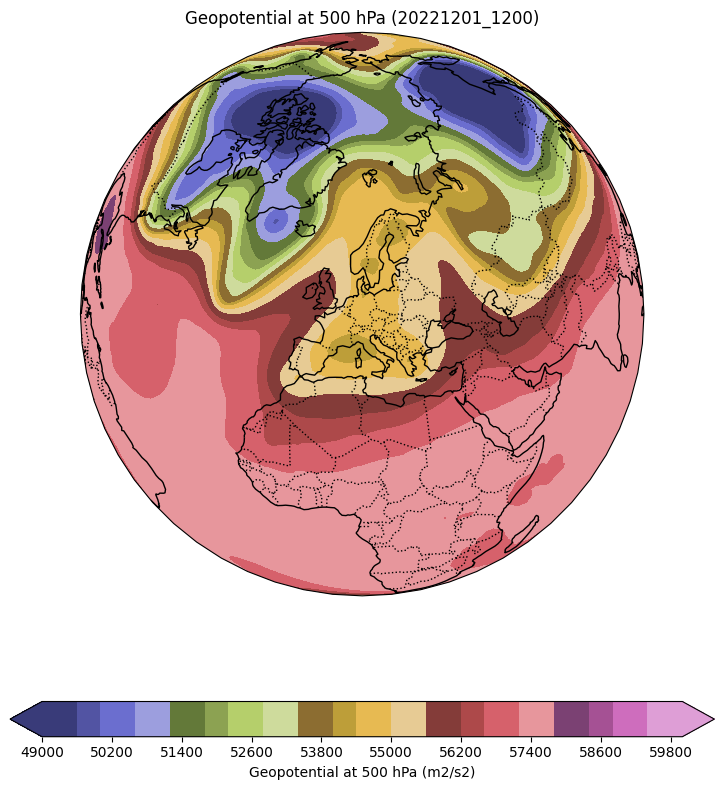

In [12]:
fCo = 2 * Omega * np.sin(lat / 360.0 * 2 * np.pi)

fig, ax = plt.subplots(figsize = (8, 8), subplot_kw={'projection': ccrs.Orthographic(central_longitude=10, central_latitude=50)})

# Set up map features
ax.set_global()
ax.coastlines(resolution='110m')
ax.add_feature(cfeature.BORDERS, lmyCminestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='k')
if myLevel == 500:
    levels_z = np.arange(49000, 60000 + 100, 200)
elif myLevel == 1000:
    levels_z = np.arange(- 3000, 4000, 200)
cmap = "tab20b"
# Plot the geopotential data
contour = plt.contourf(lon, lat, z, levels = levels_z, transform=ccrs.PlateCarree(), cmap=cmap, extend='both')
# Add color bar
plt.colorbar(contour, label="Geopotential at " + str(myLevel) + " hPa (m2/s2)", orientation='horizontal', fraction=0.05, pad=0.15)

# Add title
plt.title("Geopotential at " + str(myLevel) + " hPa (" + timeStamp + ")")
plt.tight_layout()


# Step 3: Gradient

In [14]:

def gradSpher(A, lon, lat):
    """ Returns the gradient in spherical coordinates of scalar field A with longitude lon and latitude lat provided in degrees and as 2-D arrays
    The convention for lon and lat is the same as in the ERA5 data: both are arrays with the same size as the data
    and lat is sorted by descending order
    """
    
    # Conversion to radians of lon and lat is necessary
    lam = lon / 360.0 * 2 * np.pi
    phi = lat / 360 * 2 * np.pi

    gradLam = np.full(A.shape, np.nan)
    gradPhi = np.full(A.shape, np.nan)

    gradLam[:, 1:-1] = 1 / a * np.cos(phi[:, 1:-1]) * (A[:, 2:] - A[:, :-2]) / (lam[:, 2:] - lam[:, :-2])
    # Deal with first and last columns
    gradLam[:,0]     = 1 / a * np.cos(phi[:, 0]) * (A[:, 1] - A[:, -1]) / (lam[:, 1] - lam[:, -1])
    gradLam[:,-1]    = 1 / a * np.cos(phi[:, -1]) * (A[:, 0] - A[:, -2]) / (lam[:, 0] - lam[:, -2])

    gradPhi[1:-1, :] = 1 / a * (A[:-2, :] - A[2:, :]) / (phi[:-2, :] - phi[2:, :])

    return([gradLam, gradPhi])

gradZ = gradSpher(z, lon, lat)



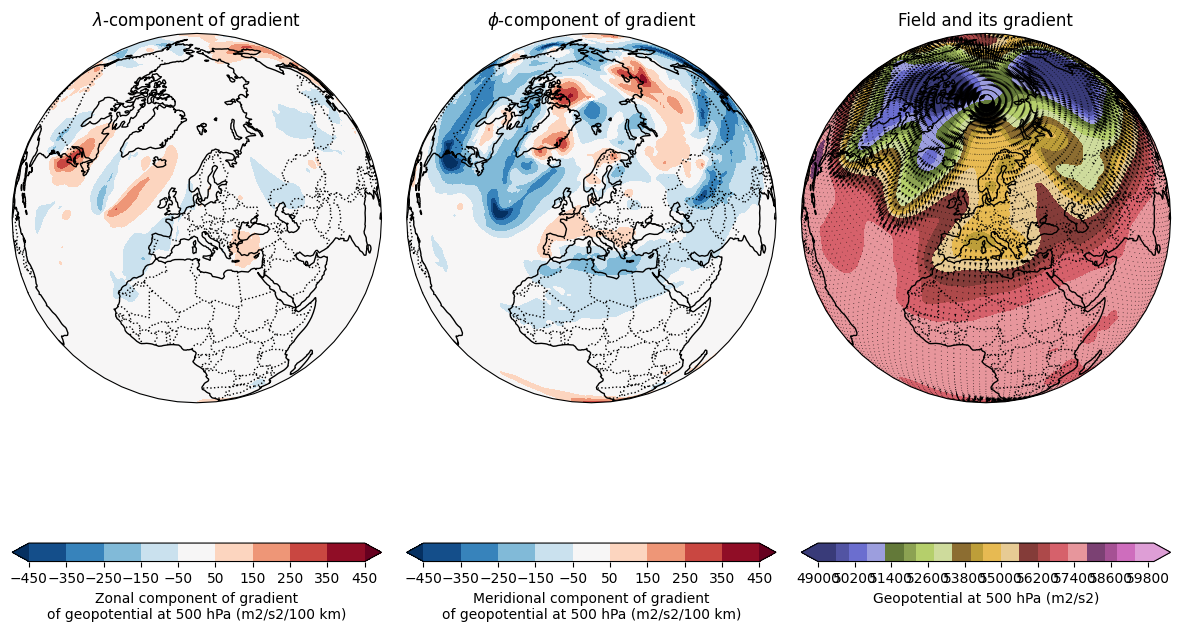

In [15]:
fig, axs = plt.subplots(1, 3, figsize = (12, 10), subplot_kw={'projection': ccrs.Orthographic(central_longitude=10, central_latitude=50)})

# Set up map features
for ax in axs:
    ax.set_global()
    ax.coastlines(resolution='110m')
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='k')

# Plot the geopotential data
jAx = 2
cmap = "tab20b"

contour = axs[jAx].contourf(lon, lat, z, levels = levels_z, transform=ccrs.PlateCarree(), cmap=cmap, extend='both')
plt.colorbar(contour, label="Geopotential at " + str(myLevel) + " hPa (m2/s2)", orientation='horizontal', fraction=0.05, pad=0.15, ax = axs[jAx])
# Plot quiver
step = 2
axs[jAx].quiver(lon[::step, ::step], lat[::step, ::step], gradZ[0][::step,::step], gradZ[1][::step,::step], scale = 0.15, transform = ccrs.PlateCarree())
axs[jAx].set_title("Field and its gradient")

# Plot the zonal component of the gradient
jAx = 0
cmap = "RdBu_r"
levels = np.arange(-450, 550, 100)
contour = axs[jAx].contourf(lon, lat, 1e5 * gradZ[0], levels = levels, transform=ccrs.PlateCarree(), cmap=cmap, extend='both')
plt.colorbar(contour, label="Zonal component of gradient\nof geopotential at " + str(myLevel) + " hPa (m2/s2/100 km)", orientation='horizontal', fraction=0.05, pad=0.15, ax = axs[jAx])
axs[jAx].set_title("$\lambda$-component of gradient")

# Plot the meridional component of the gradient
jAx = 1
cmap = "RdBu_r"
levels = np.arange(-450, 550, 100)
contour = axs[jAx].contourf(lon, lat, 1e5 * gradZ[1], levels = levels,  transform=ccrs.PlateCarree(), cmap=cmap, extend='both')
axs[jAx].set_title("$\phi$-component of gradient")
plt.colorbar(contour, label="Meridional component of gradient\nof geopotential at " + str(myLevel) + " hPa (m2/s2/100 km)", orientation='horizontal', fraction=0.05, pad=0.15, ax = axs[jAx])
plt.tight_layout()

# Step 4: Geostrophic vs. real wind

/Users/massonnetf/Library/Python/3.9/lib/python/site-packages/cartopy/crs.py:529: UserWarning: Some vectors at source domain corners may not have been transformed correctly
  warnings.warn('Some vectors at source domain corners '


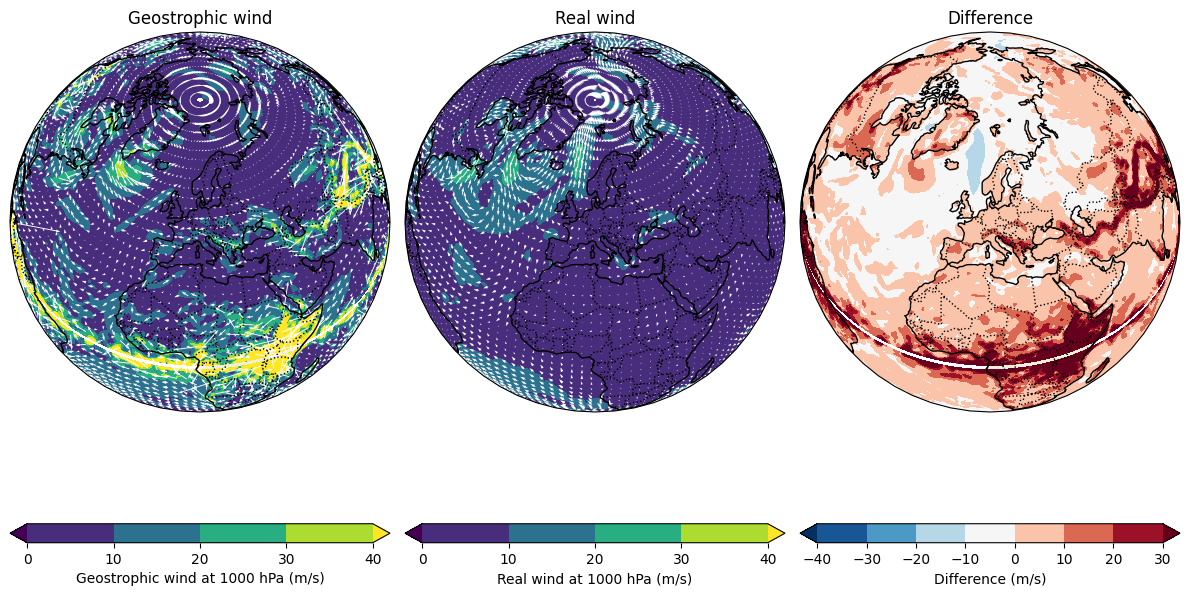

In [133]:

# Now the geostrophic wind

ug, vg = - 1 / fCo * gradZ[1], 1 / fCo * gradZ[0]
wspdg = np.sqrt(ug ** 2 + vg ** 2) # Norm of geostrophic wind

wspd = np.sqrt(u ** 2 + v ** 2) # Norm of real wind
fig, axs = plt.subplots(1, 3, figsize = (12, 8), subplot_kw={'projection': ccrs.Orthographic(central_longitude=10, central_latitude=50)})

# Set up map features
for ax in axs:
    ax.set_global()
    ax.coastlines(resolution='110m')
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='k')

# Plot the geostrophic wind data
jAx = 0
cmap = "viridis"
levels = np.arange(0, 50, 10)
contour = axs[jAx].contourf(lon, lat, wspdg, levels = levels, transform=ccrs.PlateCarree(), cmap=cmap, extend='both')
axs[jAx].set_title("Geostrophic wind")
plt.colorbar(contour, label="Geostrophic wind at " + str(myLevel) + " hPa (m/s)", orientation='horizontal', fraction=0.05, pad=0.15, ax = axs[jAx])


# Plot quiver
step = 3
axs[jAx].quiver(lon[::step, ::step], lat[::step, ::step], ug[::step,::step], vg[::step,::step], scale = 700, color = "white", transform = ccrs.PlateCarree())

# Plot the real wind data
jAx = 1
cmap = "viridis"
levels = np.arange(0, 50, 10)
contour = axs[jAx].contourf(lon, lat, wspd, levels = levels, transform=ccrs.PlateCarree(), cmap=cmap, extend='both')
axs[jAx].set_title("Real wind")
axs[jAx].quiver(lon[::step, ::step], lat[::step, ::step], u[::step,::step], v[::step,::step], scale = 700, color = "white", transform = ccrs.PlateCarree())
plt.colorbar(contour, label="Real wind at " + str(myLevel) + " hPa (m/s)", orientation='horizontal', fraction=0.05, pad=0.15, ax = axs[jAx])
plt.tight_layout()

#Plot the difference
jAx = 2
axs[jAx].set_title("Difference")
cmap = "RdBu_r"
levels = np.arange(-40, 40, 10)
contour = axs[jAx].contourf(lon, lat, wspdg - wspd, levels = levels, transform=ccrs.PlateCarree(), cmap=cmap, extend='both')
plt.colorbar(contour, label="Difference (m/s)", orientation='horizontal', fraction=0.05, pad=0.15, ax = axs[jAx])
plt.tight_layout()


In [162]:
# Step 5: Case study: Omega blocking

timeStamp = "20230905_1200"
filein = "./data/sample_" + timeStamp + ".nc"
f = Dataset(filein, mode = "r")
#print(f.variables)
# Get latitude and longitude values
step = 4 # To make plots faster
myLevel = 500
level_index = np.where(f.variables['level'][:] == myLevel)[0]
z500 = np.squeeze(f.variables["z"][0, level_index, ::step, ::step])
u500 = np.squeeze(f.variables["u"][0, level_index, ::step, ::step])
v500 = np.squeeze(f.variables["v"][0, level_index, ::step, ::step])
vo500 = np.squeeze(f.variables["vo"][0, level_index, ::step, ::step])

myLevel = 1000
level_index = np.where(f.variables['level'][:] == myLevel)[0]
z1000 = np.squeeze(f.variables["z"][0, level_index, ::step, ::step])
u1000 = np.squeeze(f.variables["u"][0, level_index, ::step, ::step])
v1000 = np.squeeze(f.variables["v"][0, level_index, ::step, ::step])
vo1000 = np.squeeze(f.variables["vo"][0, level_index, ::step, ::step])



z500, _         = add_cyclic_point(z500, coord = longitudes, axis = 1)
u500, _          = add_cyclic_point(u500, coord = longitudes, axis = 1)
v500, _          = add_cyclic_point(v500, coord = longitudes, axis = 1)
vo500, _          = add_cyclic_point(vo500, coord = longitudes, axis = 1)

z1000, _          = add_cyclic_point(z1000, coord = longitudes, axis = 1)
u1000, _          = add_cyclic_point(u1000, coord = longitudes, axis = 1)
v1000, _          = add_cyclic_point(v1000, coord = longitudes, axis = 1)
vo1000, _          = add_cyclic_point(vo1000, coord = longitudes, axis = 1)


# SLP
filein = "./data/sample_mslp_" + timeStamp + ".nc"
f = Dataset(filein, mode = "r")
msl = np.squeeze(f.variables["msl"])[::step, ::step]
msl, _          = add_cyclic_point(msl, coord = longitudes, axis = 1)

print(z500.shape)


(181, 361)


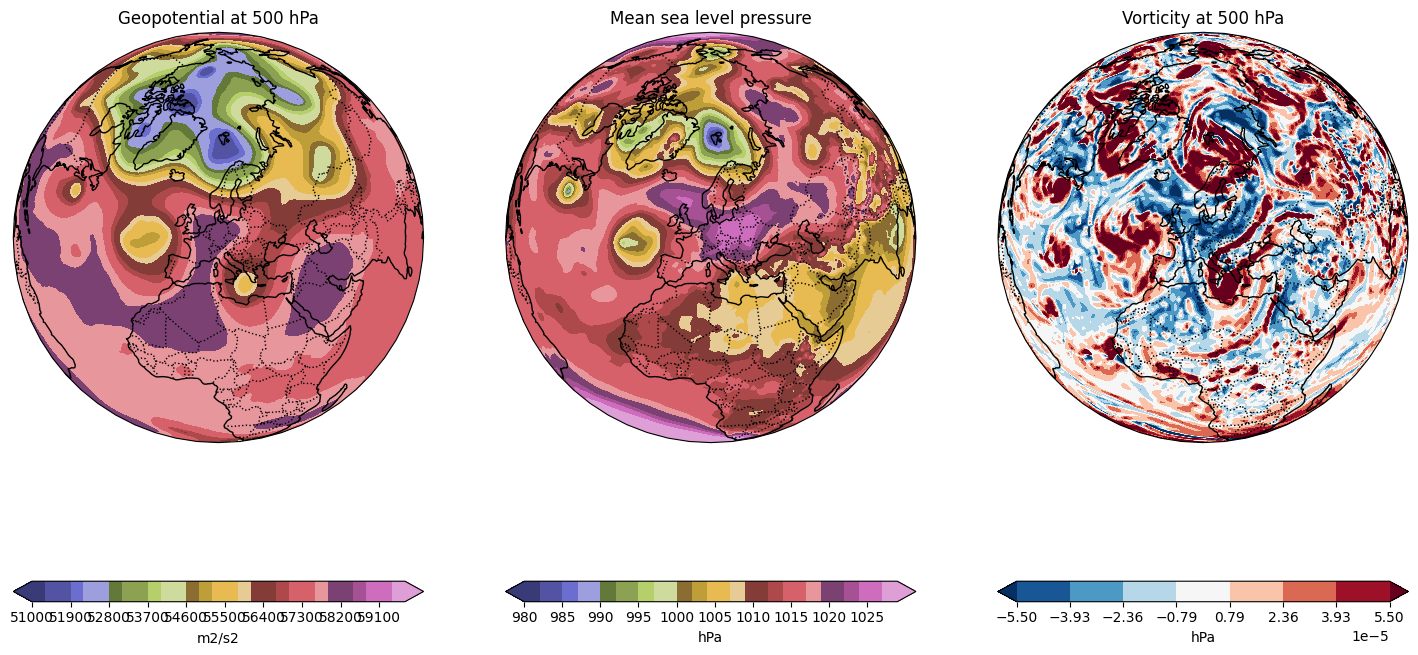

In [170]:

fig, axs = plt.subplots(1, 3, figsize = (18, 12), subplot_kw={'projection': ccrs.Orthographic(central_longitude=10, central_latitude=50)})

# Set up map features
for ax in axs.flatten():
    ax.set_global()
    ax.coastlines(resolution='110m')
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='k')

# Plot the geostrophic wind data
ax = axs[0]
cmap = "tab20b"
levels = np.arange(51000, 60000, 300)
contour = ax.contourf(lon, lat, z500, levels = levels, transform=ccrs.PlateCarree(), cmap=cmap, extend='both')
ax.set_title("Geopotential at 500 hPa")
plt.colorbar(contour, label="m2/s2", orientation='horizontal', fraction=0.05, pad=0.15, ax = ax)

ax = axs[1]
cmap = "tab20b"
levels = np.arange(980, 1030, 1)
contour = ax.contourf(lon, lat, msl / 1e2, levels = levels, transform=ccrs.PlateCarree(), cmap=cmap, extend='both')
ax.set_title("Mean sea level pressure")
plt.colorbar(contour, label="hPa", orientation='horizontal', fraction=0.05, pad=0.15, ax = ax)

ax = axs[2]
cmap = "RdBu_r"
p= 7; U = 0.55e-4; L = -U; dL = 2 * U / p; levels = np.arange(L, U + dL, dL)
contour = ax.contourf(lon, lat, vo500, levels = levels, transform=ccrs.PlateCarree(), cmap=cmap, extend='both')
ax.set_title("Vorticity at 500 hPa")
plt.colorbar(contour, label="hPa", orientation='horizontal', fraction=0.05, pad=0.15, ax = ax)

# Step N: Geostrophic vs. real wind

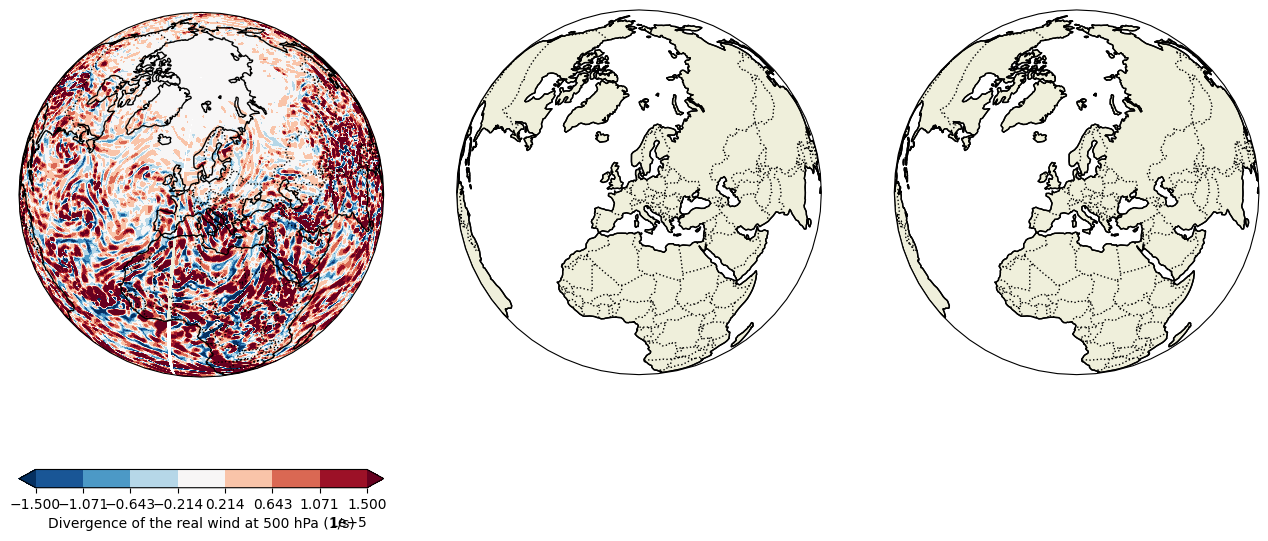

In [75]:
# Define a function to compute the divergence of a vector field
def divSpher(U, V, lon, lat):
    """ Returns the divergence in spherical coordinates of vector field (U, V) with longitude lon and latitude lat provided in degrees and as 2-D arrays
    The convention for lon and lat is the same as in the ERA5 data: both are arrays with the same size as the data
    and lat is sorted by descending order
    """
    
    # Conversion to radians of lon and lat is necessary
    lam = lon / 360.0 * 2 * np.pi
    phi = lat / 360 * 2 * np.pi

    divOut = np.full(U.shape, np.nan)

    divOut [1:-1,1:-1] = 1 / a * np.cos(phi[1:-1, 1:-1]) * (\
         (U[1:-1, 2:] - U[1:-1, :-2]) / (lam[1:-1, 2:] - lam[1:-1, :-2]) + \
         ((V * np.cos(phi))[:-2, 1:-1] - (V * np.cos(phi))[2:, 1:-1]) / (phi[:-2, 1:-1] - phi[2:, 1:-1]) )

    return divOut

div = divSpher(u, v, lon, lat)


fig, axs = plt.subplots(1, 3, figsize = (16, 8), subplot_kw={'projection': ccrs.Orthographic(central_longitude=10, central_latitude=50)})

# Set up map features
for ax in axs:
    ax.set_global()
    ax.coastlines(resolution='110m')
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='k')

# Plot the divergence of real wind data
jAx = 0
cmap = "RdBu_r"
p= 7; U = 0.15e-4; L = -U; dL = 2 * U / p; levels = np.arange(L, U + dL, dL)
contour = axs[jAx].contourf(lon, lat, div, levels = levels, transform=ccrs.PlateCarree(), cmap=cmap, extend='both')
plt.colorbar(contour, label="Divergence of the real wind at " + str(myLevel) + " hPa (1/s)", orientation='horizontal', fraction=0.05, pad=0.15, ax = axs[jAx])

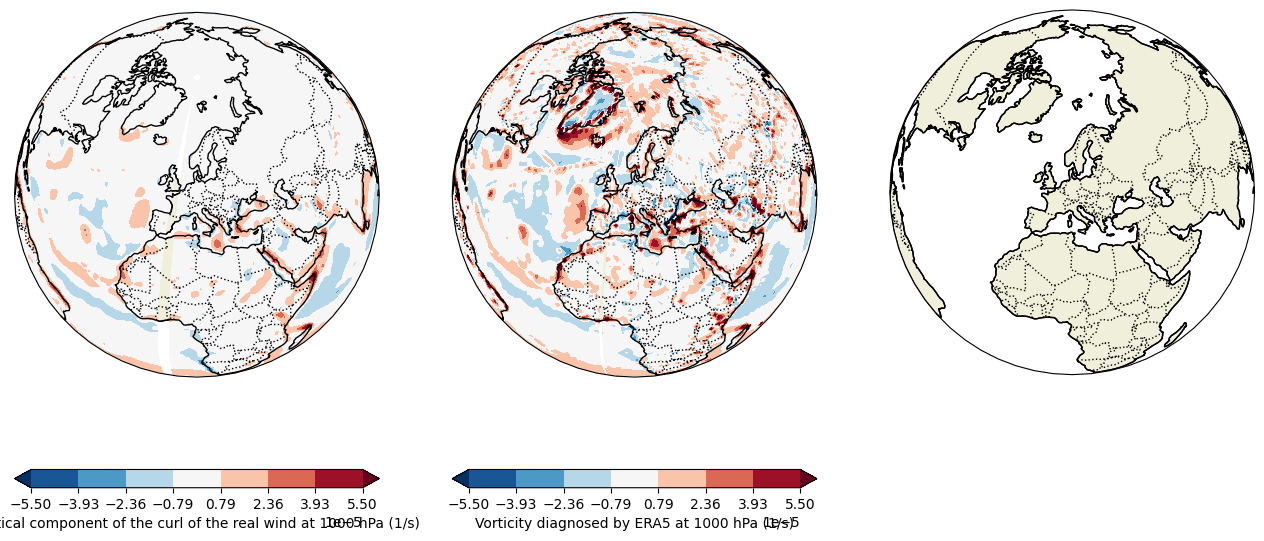

In [46]:


# Define a function to compute the vertical component of the vorticity of a vector field
def curlSpher(U, V, lon, lat):
    """ Returns the vertical component of the vorticity in spherical coordinates of vector field (U, V) with longitude lon and latitude lat provided in degrees and as 2-D arrays
    The convention for lon and lat is the same as in the ERA5 data: both are arrays with the same size as the data
    and lat is sorted by descending order
    """
    
    # Conversion to radians of lon and lat is necessary
    lam = lon / 360.0 * 2 * np.pi
    phi = lat / 360 * 2 * np.pi

    curlOut = np.full(U.shape, np.nan)

    curlOut [1:-1,1:-1] = 1 / a * np.cos(phi[1:-1, 1:-1]) * (V[1:-1, 2:] - V[1:-1, :-2]) / (lam[1:-1, 2:] - lam[1:-1, :-2]) - \
    1 / a * np.cos(phi[1:-1, 1:-1]) * (U[:-2, 1:-1] * np.cos(phi[:-2, 1:-1]) - U[2:, 1:-1] * np.cos(phi[2:, 1:-1])) / (phi[:-2, 1:-1] - phi[2:, 1:-1])

    return curlOut

curl = curlSpher(u, v, lon, lat)

fig, axs = plt.subplots(1, 3, figsize = (16, 8), subplot_kw={'projection': ccrs.Orthographic(central_longitude=10, central_latitude=50)})

# Set up map features
for ax in axs:
    ax.set_global()
    ax.coastlines(resolution='110m')
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='k')

# Plot the curl of real wind data = relative vorticity
jAx = 0
cmap = "RdBu_r"
p= 7; U = 0.55e-4; L = -U; dL = 2 * U / p; levels = np.arange(L, U + dL, dL)
contour = axs[jAx].contourf(lon, lat, curl, levels = levels, transform=ccrs.PlateCarree(), cmap=cmap, extend='both')
plt.colorbar(contour, label="Vertical component of the curl of the real wind at " + str(myLevel) + " hPa (1/s)", orientation='horizontal', fraction=0.05, pad=0.15, ax = axs[jAx])

# Plot the vorticity as output in ERA5
jAx = 1
cmap = "RdBu_r"
p= 7; U = 0.55e-4; L = -U; dL = 2 * U / p; levels = np.arange(L, U + dL, dL)
contour = axs[jAx].contourf(lon, lat, vo, levels = levels, transform=ccrs.PlateCarree(), cmap=cmap, extend='both')
plt.colorbar(contour, label="Vorticity diagnosed by ERA5 at " + str(myLevel) + " hPa (1/s)", orientation='horizontal', fraction=0.05, pad=0.15, ax = axs[jAx])


# Plot f + curl of relative vorticity
#jAx = 2
#cmap = "RdBu_r"
#p= 7; U = 2.0e-4; L = -U; dL = 2 * U / p; levels = np.arange(L, U + dL, dL)
#contour = axs[jAx].contourf(lon, lat, curl + fCo, levels = levels, transform=ccrs.PlateCarree(), cmap=cmap, extend='both')
#plt.colorbar(contour, label="Vertical component of the absolute vorticity " + str(myLevel) + " hPa (1/s)", orientation='horizontal', fraction=0.05, pad=0.15, ax = axs[jAx])
